In [1]:
#setup 

import torch
import random
import matplotlib.pyplot as plt
import torchvision
from torch import nn
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import os

if not os.path.exists('./dc_img'):
    os.mkdir('./dc_img')
    
print ("setup done")

setup done


In [2]:
#helper functions
def to_img(x):
    x = 0.5 * (x + 1)
    x = x.clamp(0, 1)
    x = x.view(x.size(0), 1, 28, 28)
    return x

In [3]:
#hyperparameters
num_epochs = 10
batch_size = 128
learning_rate = 1e-3

In [4]:
#Data loading
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

dataset = MNIST('./data', transform=img_transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print("Number of batches:", len(dataloader))



Number of batches: 469


In [5]:
#add noise to the image
def add_noise(img, sigma=0.2):
    noise = torch.randn_like(img) * sigma
    noisy_img = img + noise
    noisy_img = torch.clamp(noisy_img, -1., 1.)  # keep same range
    return noisy_img

In [6]:
#Model definition
class autoencoder(nn.Module):
    def __init__(self):
        super(autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=3, padding=1),  # b, 16, 10, 10
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),  # b, 16, 5, 5
            nn.Conv2d(16, 8, 3, stride=2, padding=1),  # b, 8, 3, 3
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=1)  # b, 8, 2, 2
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, 3, stride=2),  # b, 16, 5, 5
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 5, stride=3, padding=1),  # b, 8, 15, 15
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, 2, stride=2, padding=1),  # b, 1, 28, 28
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

print ("model defined")


model defined


In [7]:
#Model and optimizer
model = autoencoder()

# load model if exists, after finalizing on the model, this can be used.
#if os.path.exists("conv_autoencoder.pth"):
    #model.load_state_dict(torch.load("conv_autoencoder.pth"))
    #print("Loaded previous model weights")
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,
                             weight_decay=1e-5)

In [8]:
#visualize of noise and denoising.
# using noise of 0.3, strong noise to test quality of reconstruction
def visualize(model, dataloader, epoch, sigma=0.3):
    img, _ = next(iter(dataloader))

    noisy_img = add_noise(img, sigma)

    # no_grad (forward pass only,since we are using the resulted weights)
    with torch.no_grad():
        output = model(noisy_img)

    orig = to_img(img)
    noisy = to_img(noisy_img)
    recon = to_img(output)

    plt.figure(figsize=(9,3))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(orig[0][0], cmap='gray') #plot first image in batch

    plt.subplot(1,3,2)
    plt.title(f"Noisy σ={sigma}")
    plt.imshow(noisy[0][0], cmap='gray')

    plt.subplot(1,3,3)
    plt.title("Reconstructed")
    plt.imshow(recon[0][0], cmap='gray')

    plt.suptitle(f"Epoch {epoch}")
    plt.show()

Epoch [1/10], Loss: 0.1161


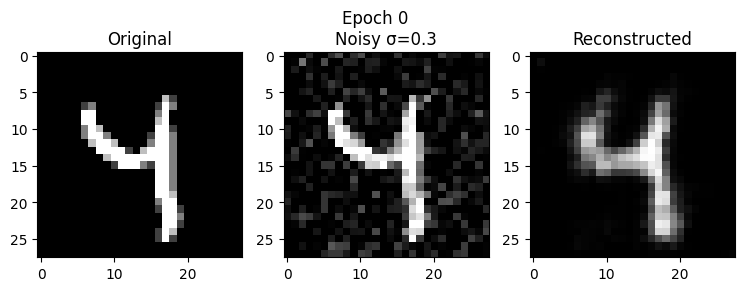

Epoch [2/10], Loss: 0.1148
Epoch [3/10], Loss: 0.1134
Epoch [4/10], Loss: 0.1124
Epoch [5/10], Loss: 0.1118
Epoch [6/10], Loss: 0.1109
Epoch [7/10], Loss: 0.1097
Epoch [8/10], Loss: 0.1091
Epoch [9/10], Loss: 0.1086
Epoch [10/10], Loss: 0.1081


In [12]:
#Training loop
losses= [] #to stores lose for each epoch to plot.
for epoch in range(num_epochs):
    total_loss = 0
    for data in dataloader:
        img, _ = data
        img = Variable(img)
        sigma = random.choice([0.1, 0.2, 0.3])
        noisy_img = add_noise(img, sigma=sigma)
        # ===================forward=====================
        output = model(noisy_img)
        loss = criterion(output, img)
        # ===================backward====================
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    # ===================log========================
    
    avg_loss = total_loss / len(dataloader) #avergae loss per epoch
    losses.append(avg_loss) #store average loss per epochfor plotting later
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}") #print the avg loss for each epoch
    if epoch % 10 == 0:
        visualize(model, dataloader, epoch) # visualize every 10 epochs
        pic = to_img(output.cpu().data)
        save_image(pic, './dc_img/image_{}.png'.format(epoch)) #saves images from the batch (recosntructed images) in a grid layout

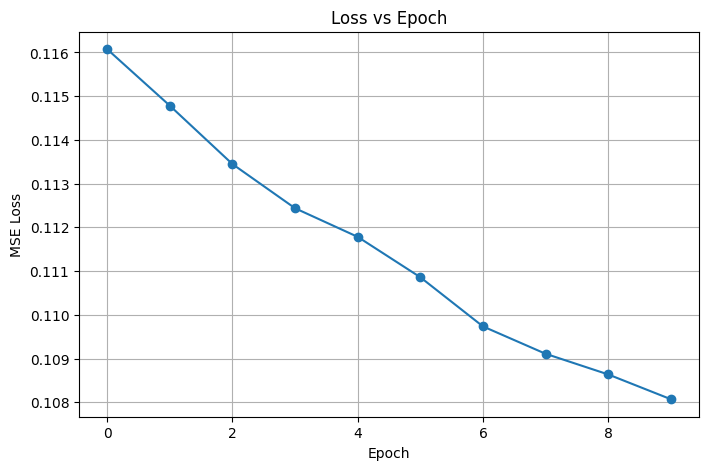

In [13]:
#plotting the loss curve
plt.figure(figsize=(8,5))
plt.plot(losses, marker='o')
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

In [14]:
#save model
torch.save(model.state_dict(), './conv_autoencoder.pth')